In [1]:
import os
from pyexpat import model
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import torch
import torchvision.models as models
import torch.nn as nn
import torch.optim as optim
from tqdm import tqdm
from torch.optim.lr_scheduler import ReduceLROnPlateau
import matplotlib.pyplot as pltzzzz  
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc
from sklearn.multiclass import OneVsRestClassifier
from sklearn.metrics import RocCurveDisplay
import numpy as np
from matplotlib import pyplot as plt

# dataset path
data_dir = r"C:\Users\sahba\Downloads\archive (2)\IMG_CLASSES"

# augmentation
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomResizedCrop(224, scale=(0.8, 1.0)),

    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], 
                         [0.229, 0.224, 0.225])
])

# loading the dataset
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)


print("Classes:", full_dataset.classes)

from torch.utils.data import random_split, DataLoader

# calculating sizes for train, val, and test (70%, 15%, 15%)
total_size = len(full_dataset)
train_size = int(0.7 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size 

# spliting the dataset
train_dataset, val_dataset, test_dataset = random_split(full_dataset, [train_size, val_size, test_size])

# creating DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)


Classes: ['C', 'M', 'MN', 'R', 'SK', 'WM']


In [ ]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(torch.cuda.get_device_name(0)) 

# 1️⃣  Load a pretrained AlexNet
model = models.alexnet(weights=models.AlexNet_Weights.IMAGENET1K_V1)

# 2️⃣  Freeze *every* parameter first …
for p in model.parameters():
    p.requires_grad = False
# 3️⃣  …then selectively unfreeze the last two convolutional layers
# AlexNet’s conv layers sit in model.features[0-4] (conv1-conv5):
#     conv3 → index 2
#     conv4 → index 3
#     conv5 → index 4
for idx in (3, 4):                      # conv4 and conv5
    for p in model.features[idx].parameters():
        p.requires_grad = True

# 4️⃣  Replace the classifier head
num_classes = 6        
in_feat = model.classifier[6].in_features   # 4096 for AlexNet

model.classifier[6] = nn.Sequential(
    nn.Linear(in_feat, 512),
    nn.ReLU(),
    nn.Dropout(p=0.4),
    nn.Linear(512, num_classes),
)

# 5️⃣  Sanity-check: parameters that require grad
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params     = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable_params:,} / {total_params:,}")

model = model.to(device)

Using device: cuda
NVIDIA GeForce RTX 4060 Laptop GPU
Trainable params: 2,408,134 / 59,104,582


In [3]:
# number of samples per class
class_counts = [
    2697,    # Melanoma
    2215,    # Carcinoma
    6946,    # Melanocytic_Nevi
    1827,    # Seborrheic_Keratoses
    1644,    # TineaRingwormCandidiasis
    1888     # WartsMolluscum
]

# converting to tensor and compute weights
class_counts_tensor = torch.tensor(class_counts, dtype=torch.float)
class_weights = 1.0 / class_counts_tensor
class_weights = class_weights / class_weights.sum() * len(class_counts)  # normalization to match number of classes
class_weights = class_weights.to(device) 
print("Class weights:", class_weights)

Class weights: tensor([0.8390, 1.0216, 0.3258, 1.2386, 1.3764, 1.1986], device='cuda:0')


In [4]:
# hyperparameters
num_epochs = 75
learning_rate = 0.001

# loss function
criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# optimizer
optimizer = optim.Adam([
    {'params': model.features[3].parameters(), 'lr': 1e-6},  # conv4
    {'params': model.features[4].parameters(), 'lr': 1e-5},  # conv5
    {'params': model.classifier[6].parameters(), 'lr': 1e-3}  # custom FC head
])
scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.5, verbose=True)

c:\Users\sahba\AppData\Local\Programs\Python\Python39\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(



Epoch [1/75]


Train Loss: 1.1768, Train Acc: 66.59%
Val Loss: 1.0341, Val Acc: 74.95%

Epoch [2/75]


Train Loss: 1.0792, Train Acc: 72.89%
Val Loss: 0.9985, Val Acc: 76.19%

Epoch [3/75]


Train Loss: 1.0416, Train Acc: 74.90%
Val Loss: 0.9651, Val Acc: 81.97%

Epoch [4/75]


Train Loss: 1.0163, Train Acc: 76.06%
Val Loss: 0.9639, Val Acc: 77.82%

Epoch [5/75]


...

Train Loss: 0.7457, Train Acc: 89.86%
Val Loss: 0.8478, Val Acc: 85.73%

Epoch [72/75]


Train Loss: 0.7393, Train Acc: 90.15%
Val Loss: 0.8339, Val Acc: 86.31%

Epoch [73/75]


Train Loss: 0.7435, Train Acc: 90.11%
Val Loss: 0.8401, Val Acc: 85.73%

Epoch [74/75]


Train Loss: 0.7420, Train Acc: 89.66%
Val Loss: 0.8436, Val Acc: 86.12%

Epoch [75/75]


Train Loss: 0.7427, Train Acc: 89.65%
Val Loss: 0.8337, Val Acc: 86.20%


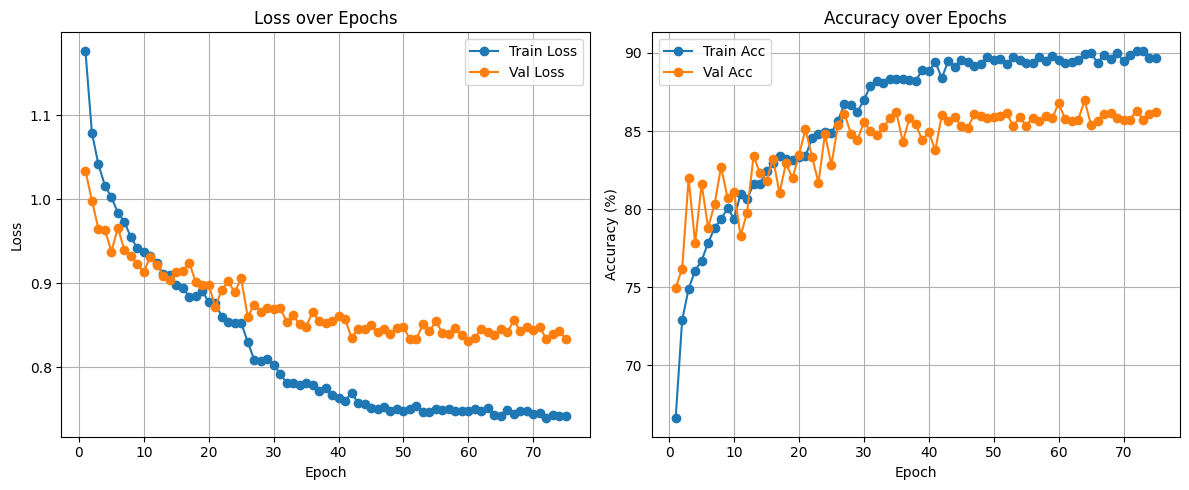

In [5]:


# metrics
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

# Training and validation loop
for epoch in range(num_epochs):
    print(f"\nEpoch [{epoch+1}/{num_epochs}]")

    # ----- Training -----
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    loop = tqdm(train_loader, desc="Training", leave=False)
    for images, labels in loop:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        loop.set_postfix(loss=loss.item())

    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)


    print(f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    
    # ----- Validation -----
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    val_loss = running_loss / len(val_loader)
    val_acc = 100. * correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
    scheduler.step(val_loss)
   
    # ------ Plotting ------
epochs = range(1, num_epochs + 1)

plt.figure(figsize=(12, 5))

# Loss Plot
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.plot(epochs, val_losses, label='Val Loss', marker='o')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy Plot
plt.subplot(1, 2, 2)
plt.plot(epochs, train_accuracies, label='Train Acc', marker='o')
plt.plot(epochs, val_accuracies, label='Val Acc', marker='o')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [6]:

model.eval()
test_loss = 0.0
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        test_loss += criterion(outputs, labels).item()

        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calculate average test loss
avg_test_loss = test_loss / len(test_loader)
print(f"\nTest Loss: {avg_test_loss:.4f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=full_dataset.classes))



Test Loss: 0.8396

Classification Report:
              precision    recall  f1-score   support

           C       0.85      0.97      0.90       330
           M       0.81      0.89      0.85       427
          MN       0.95      0.88      0.92      1056
           R       0.76      0.78      0.77       224
          SK       0.76      0.78      0.77       265
          WM       0.81      0.75      0.78       278

    accuracy                           0.86      2580
   macro avg       0.82      0.84      0.83      2580
weighted avg       0.86      0.86      0.86      2580



C:\Users\sahba\AppData\Local\Temp\ipykernel_8312\3837580526.py:32: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", num_classes)


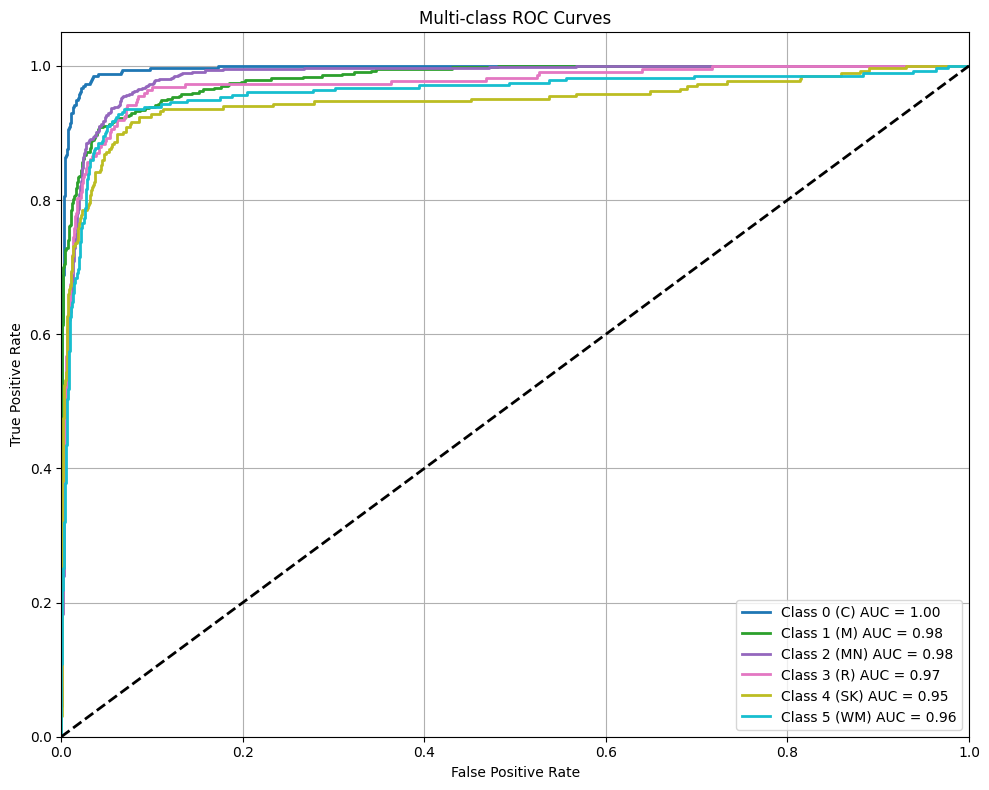

In [10]:


# 1️⃣ Get softmax probabilities and true labels
all_probs = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        probs = torch.softmax(outputs, dim=1)  # convert logits to probabilities
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

# 2️⃣ Binarize the labels (for multi-class ROC)
from sklearn.preprocessing import label_binarize
all_labels_bin = label_binarize(all_labels, classes=np.arange(num_classes))  # shape: [n_samples, n_classes]

# 3️⃣ Compute ROC curve and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(num_classes):
    fpr[i], tpr[i], _ = roc_curve(all_labels_bin[:, i], all_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 4️⃣ Plot all ROC curves
plt.figure(figsize=(10, 8))
colors = plt.cm.get_cmap("tab10", num_classes)

for i in range(num_classes):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f'Class {i} ({full_dataset.classes[i]}) AUC = {roc_auc[i]:.2f}')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curves')
plt.legend(loc='lower right')
plt.grid(True)
plt.tight_layout()
plt.show()


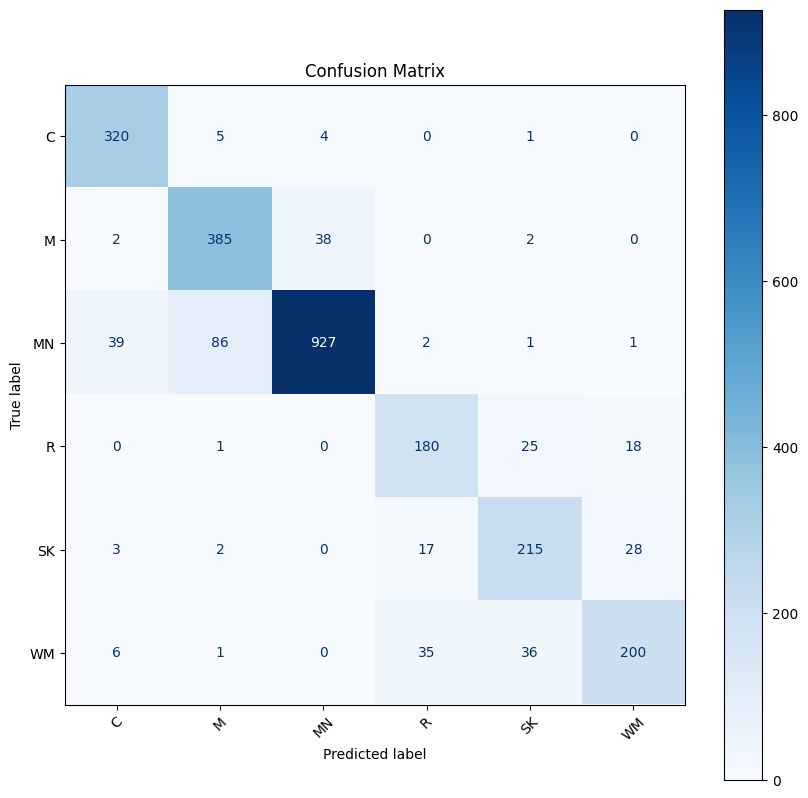

In [13]:

# Collect all predictions and true labels




all_preds = []
all_labels = []

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute confusion matrix
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=full_dataset.classes)
fig, ax = plt.subplots(figsize=(10, 10))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix")
plt.show()

In [9]:
# Save the model
torch.save(model.state_dict(), "AlexNet001.pth")